# Mini Project Interpretability & Explainability in AI: Discovering Emojis as a concept inside the brain of LLMs
## Part 2: Sparse AutoEncoder acitvation perturbations
### Final Grade: 9/10 
Code structure adapted from https://arena3-chapter1-transformer-interp.streamlit.app/ and  https://youtu.be/UGO_Ehywuxc

In [ ]:
import os, sys

IN_COLAB = "google.colab" in sys.modules
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
if IN_COLAB:
    %pip install "torch>=2.1.0" einops datasets jaxtyping "sae_lens>=3.23.1" openai tabulate "nbformat>=4.2.0" umap-learn hdbscan eindex-callum git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python git+https://github.com/callummcdougall/sae_vis.git@callum/v3 "transformer-lens>=2.7.0"
else:
    %pip install "torch>=2.1.0" einops datasets jaxtyping "sae_lens>=3.23.1" openai tabulate "nbformat>=4.2.0" umap-learn hdbscan eindex-callum git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python git+https://github.com/callummcdougall/sae_vis.git@callum/v3 "transformer-lens>=2.7.0"

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/callummcdougall/CircuitsVis.git to /gpfs/scratch1/nodespecific/gcn2/scur1226.12641305/pip-req-build-ipixmh4e
  Running command git clone --filter=blob:none --quiet https://github.com/callummcdougall/CircuitsVis.git /gpfs/scratch1/nodespecific/gcn2/scur1226.12641305/pip-req-build-ipixmh4e
  Resolved https://github.com/callummcdougall/CircuitsVis.git to commit 1e6129d08cae7af9242d9ab5d3ed322dd44b4dd3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/callummcdougall/sae_vis.git (to revision callum/v3) to /gpfs/scratch1/nodespecific/gcn2/scur1226.12641305/pip-req-build-1gjxrewr
  Running command git clone --filter=blob:none --quiet https://github.com/callummcdougall/sae_vis.git /gpfs/scratch1/nodespecific/gcn2/scur1226.12641305/pip-req-build-1gjxrewr
  Running command git 

In [ ]:
# define functions and imports

import os, sys

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%pip install "torch>=2.1.0" einops datasets jaxtyping "sae_lens>=3.23.1" openai tabulate "nbformat>=4.2.0" umap-learn hdbscan eindex-callum git+https://github.com/callummcdougall/CircuitsVis.git#subdirectory=python git+https://github.com/callummcdougall/sae_vis.git@callum/v3 "transformer-lens>=2.7.0"

from IPython.display import HTML, IFrame, clear_output, display
import random
from rich import print as rprint
from rich.table import Table
from tqdm.auto import tqdm
from functools import partial
import torch as t
import torch.nn.functional as F
from torch import Tensor, nn
from jaxtyping import Float, Int
import einops

import matplotlib.pyplot as plt
import numpy as np

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")

from sae_lens.toolkit.pretrained_saes_directory import get_pretrained_saes_directory
from sae_lens import (
    SAE,
    ActivationsStore,
    HookedSAETransformer,
    LanguageModelSAERunnerConfig,
    SAEConfig,
    SAETrainingRunner,
    upload_saes_to_huggingface,
)

from transformer_lens import ActivationCache, HookedTransformer, utils
from transformer_lens.hook_points import HookPoint
from tabulate import tabulate

#from google.colab import drive
import pickle, glob

def display_dashboard(
    sae_release="gpt2-small-res-jb",
    sae_id="blocks.7.hook_resid_pre",
    latent_idx=0,
    width=1200,
    height=800,
):
    release = get_pretrained_saes_directory()[sae_release]
    neuronpedia_id = release.neuronpedia_id[sae_id]

    url = f"https://neuronpedia.org/{neuronpedia_id}/{latent_idx}?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"

    print(url)
    display(IFrame(url, width=width, height=height))

def steering_hook(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    return activations + steering_coefficient * sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.


def generate_with_steering( #Ah I could do a version of this for neurons - right!
    model: HookedSAETransformer,
    sae: SAE,
    prompt: str,
    latent_idx: int,
    steering_coefficient: float = 1.0,
    max_new_tokens: int = 50,
):
    """
    Generates text with steering. A multiple of the steering vector (the decoder weight for this latent) is added to
    the last sequence position before every forward pass.
    """
    _steering_hook = partial(
        steering_hook,
        sae=sae,
        latent_idx=latent_idx,
        steering_coefficient=steering_coefficient,
    )

    with model.hooks(fwd_hooks=[(sae.cfg.hook_name, _steering_hook)]):
        output = model.generate(prompt, max_new_tokens=max_new_tokens, **GENERATE_KWARGS)

    return output

#utils.test_prompt(prompt, answer, gemma_2_2b,prepend_bos=True)



 

import inspect

def get_func_args(func):
    sig = inspect.signature(func)
    return {
        "args": [
            param.name
            for param in sig.parameters.values()
            if param.kind in (param.POSITIONAL_OR_KEYWORD, param.KEYWORD_ONLY)
        ],
        "defaults": {
            param.name: param.default
            for param in sig.parameters.values()
            if param.default is not param.empty
        },
    }




from huggingface_hub import login


prompt_emoji = "A random emoji:\n🎉\n😎\n🍕\n🚀\n🌈\n🚀\n😒\n"
prompt_word = "A random English word:\nsun\nriver\ncloud\nstone\nforest\ncold\nmirror\n"


gemma_2_2b = HookedSAETransformer.from_pretrained("gemma-2-2b", device=device)
layer = 24

release = "gemma-2-2b-res-matryoshka-dc"
sae_id = f"blocks.{layer}.hook_resid_post"

gemma_2_2b_sae = SAE.from_pretrained(release, sae_id, device=str(device))[0]

_, cache_emoji = gemma_2_2b.run_with_cache_with_saes(prompt_emoji, saes=[gemma_2_2b_sae])

_, cache_word = gemma_2_2b.run_with_cache_with_saes(prompt_word, saes=[gemma_2_2b_sae])


for name, param in cache_emoji.items():
    if "hook_sae" in name:
        print(f"{name:<43}: {tuple(param.shape)}")
        



saespace_acts_post_word = cache_word[f"blocks.{layer}.hook_resid_post.hook_sae_acts_post"][0, -1, :].detach().cpu()
saespace_acts_post_emoji = cache_emoji[f"blocks.{layer}.hook_resid_post.hook_sae_acts_post"][0, -1, :].detach().cpu()

normed_sparsedspace_post = saespace_acts_post_emoji - saespace_acts_post_word


vals, indices = torch.sort(normed_sparsedspace_post,descending=True) # llooking at high activs
indices_high = torch.where(vals> 0)

inspect_list = [] 
for i in zip(vals[indices_high],indices[indices_high]):
    inspect_list.append(i)

indices_inspect = indices[indices_high]
inspect_list 


import torch 
latent_idx = [indices_inspect[0].item(),indices_inspect[2].item()] # layer 24

def steering_hook_sparsespace(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    # w_dec gets for a certain sparse space idx the activations pattern, and then we add it
    if isinstance(latent_idx,int):
        return activations + steering_coefficient *sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.
    else: #multi indx
        #print("enhancing multiple concepts")
        return activations + steering_coefficient *torch.mean(sae.W_dec[latent_idx],dim=0,keepdim=False) #Hmm wow how can we visualize this - interesting. Pretty simple in a way.




_steering_hook = partial(
    steering_hook_sparsespace,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=600,
)

context = "Afterwards he"

sample_tokens = True
preprend_bos_token = True
samples = 3 

# without tweak
for i in range(samples):
    print(gemma_2_2b.generate(context,prepend_bos=preprend_bos_token,do_sample=sample_tokens,temperature=1.5, freq_penalty=2.0, verbose=False))


# with tweak
with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
    for i in range(samples):
        print(gemma_2_2b.generate(context,prepend_bos=preprend_bos_token,do_sample=sample_tokens,temperature=1.5, freq_penalty=2.0, verbose=False))
    
        

/home/scur1226/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from huggingface_hub import login



## Polysemanticity and Superposition

In [5]:
gemma_2_2b = HookedSAETransformer.from_pretrained("gemma-2-2b", device=device)


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00, 12.94it/s]


Loaded pretrained model gemma-2-2b into HookedTransformer


In [ ]:
layer = 24 # from layer 21 onwards gives most functional activations, with layer 24 the most influential -> sign that emoji as concept only later in model 

release = "gemma-2-2b-res-matryoshka-dc"
sae_id = f"blocks.{layer}.hook_resid_post"

gemma_2_2b_sae = SAE.from_pretrained(release, sae_id, device=str(device))[0]


/home/scur1226/.local/lib/python3.11/site-packages/sae_lens/sae.py:151: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [ ]:
#prompt = "<start_of_turn>user Reply with exactly one random English word. No punctuation. No space. No explanation. Only the word. <end_of_turn> <start_of_turn>model"
#prompt = "<start_of_turn>user Each line below contains only one random emoji. Follow the pattern. DO NOT add words, punctuation, or explanations — only output one emoji character. <end_of_turn> <start_of_turn>model "
# works good for instruction tuned,  not for regular gemma


#prompt_word = "A common word in the English dictionary"
#prompt_emoji = "A common emoji in the English dictionary is "


prompt_emoji = "A random emoji:\n🎉\n😎\n🍕\n🚀\n🌈\n🚀\n😒\n"
prompt_word = "A random English word:\nsun\nriver\ncloud\nstone\nforest\ncold\nmirror\n"


In [8]:
answer = ""
utils.test_prompt(prompt_word, answer, gemma_2_2b,prepend_bos=True)

Tokenized prompt: ['<bos>', 'A', ' random', ' English', ' word', ':', '\n', 'sun', '\n', 'river', '\n', 'cloud', '\n', 'stone', '\n', 'forest', '\n', 'cold', '\n', 'mirror', '\n']
Tokenized answer: [' ']


Performance on answer token:
Rank: 161      Logit: 21.63 Prob:  0.07% Token: | |

Top 0th token. Logit: 25.87 Prob:  5.04% Token: |tree|
Top 1th token. Logit: 25.77 Prob:  4.54% Token: |wind|
Top 2th token. Logit: 25.68 Prob:  4.15% Token: |moon|
Top 3th token. Logit: 25.57 Prob:  3.72% Token: |fire|
Top 4th token. Logit: 25.42 Prob:  3.19% Token: |sun|
Top 5th token. Logit: 25.39 Prob:  3.11% Token: |snow|
Top 6th token. Logit: 25.27 Prob:  2.76% Token: |mountain|
Top 7th token. Logit: 25.24 Prob:  2.66% Token: |water|
Top 8th token. Logit: 25.12 Prob:  2.36% Token: |sky|
Top 9th token. Logit: 25.10 Prob:  2.32% Token: |lake|


Ranks of the answer tokens: [(' ', 161)]

In [9]:
answer = ""
utils.test_prompt(prompt_emoji, answer, gemma_2_2b,prepend_bos=True)

Tokenized prompt: ['<bos>', 'A', ' random', ' emoji', ':', '\n', '🎉', '\n', '😎', '\n', '🍕', '\n', '🚀', '\n', '🌈', '\n', '🚀', '\n', '😒', '\n']
Tokenized answer: [' ']


Performance on answer token:
Rank: 332      Logit: 20.53 Prob:  0.02% Token: | |

Top 0th token. Logit: 26.02 Prob:  5.63% Token: |😎|
Top 1th token. Logit: 25.56 Prob:  3.56% Token: |🎉|
Top 2th token. Logit: 25.25 Prob:  2.61% Token: |😒|
Top 3th token. Logit: 25.17 Prob:  2.42% Token: |😂|
Top 4th token. Logit: 25.14 Prob:  2.34% Token: |👍|
Top 5th token. Logit: 25.01 Prob:  2.06% Token: |🚀|
Top 6th token. Logit: 24.94 Prob:  1.91% Token: |😊|
Top 7th token. Logit: 24.79 Prob:  1.65% Token: |😍|
Top 8th token. Logit: 24.78 Prob:  1.63% Token: |💩|
Top 9th token. Logit: 24.77 Prob:  1.61% Token: |🌈|


Ranks of the answer tokens: [(' ', 332)]

In [10]:
_, cache_emoji = gemma_2_2b.run_with_cache_with_saes(prompt_emoji, saes=[gemma_2_2b_sae])

_, cache_word = gemma_2_2b.run_with_cache_with_saes(prompt_word, saes=[gemma_2_2b_sae])


for name, param in cache_emoji.items():
    if "hook_sae" in name:
        print(f"{name:<43}: {tuple(param.shape)}")
        

blocks.24.hook_resid_post.hook_sae_input   : (1, 20, 2304)
blocks.24.hook_resid_post.hook_sae_acts_pre: (1, 20, 32768)
blocks.24.hook_resid_post.hook_sae_acts_post: (1, 20, 32768)
blocks.24.hook_resid_post.hook_sae_recons  : (1, 20, 2304)
blocks.24.hook_resid_post.hook_sae_output  : (1, 20, 2304)


# neurons

In [11]:
# Get sparse neuron activations on final token
sae_acts_post_word = cache_word[f"{gemma_2_2b_sae.cfg.hook_name}.hook_sae_output"][0, -1, :].detach().cpu()
sae_acts_post_emoji = cache_emoji[f"{gemma_2_2b_sae.cfg.hook_name}.hook_sae_output"][0, -1, :].detach().cpu()

normed_sparsed = sae_acts_post_emoji - sae_acts_post_word

In [12]:
# get input to sparse of final token
base_input=cache_word[f'blocks.{layer}.hook_resid_post.hook_sae_input'][0, -1, :].detach().cpu()
emo_input=cache_emoji[f'blocks.{layer}.hook_resid_post.hook_sae_input'][0, -1, :].detach().cpu()

normed_input = emo_input - base_input
# m=cache['blocks.20.attn.hook_z.hook_sae_input']
#m.shape

neurons before sparsing


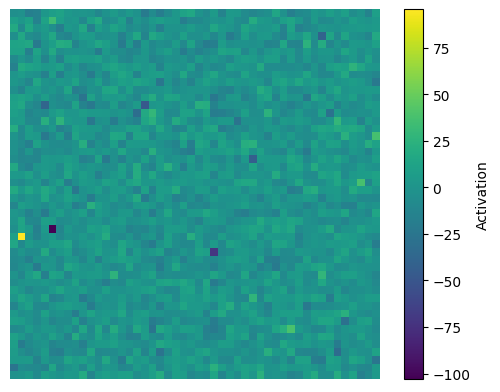

In [41]:
print("neurons before sparsing")
plt.imshow(normed_input.numpy().reshape(48,48))
plt.colorbar(label="Activation")  # optional: adds a color scale legend
plt.xlabel("Hidden Neurons Index X-axis ")
plt.ylabel("Hidden Neurons Index Y-axis ")
plt.axis('off')
plt.show()

neurons after sparsing using SAE


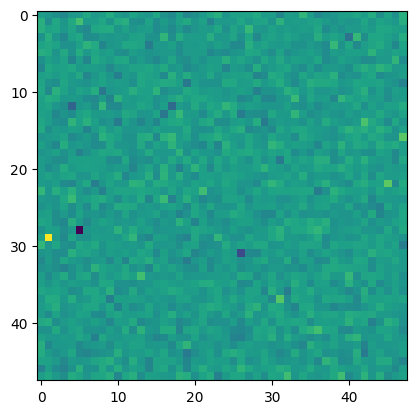

In [14]:
print("neurons after sparsing using SAE")
plt.imshow(normed_sparsed.numpy().reshape(48,48))

In [15]:
import torch 
indices = torch.where(normed_sparsed > normed_sparsed.min() +((normed_sparsed.max()-normed_sparsed.min())*0.75))[0]


def steering_hook_multi(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    mask = torch.zeros_like(activations).to(device=activations.device)
    mask[:,-1,latent_idx] = 1
    return activations + steering_coefficient * mask* activations
    
    #return activations + steering_coefficient #* mask


_steering_hook = partial(
    steering_hook_multi,
    sae=gemma_2_2b_sae,
    latent_idx=indices,
    steering_coefficient=700,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt_word, answer, gemma_2_2b)

Tokenized prompt: ['<bos>', 'A', ' random', ' English', ' word', ':', '\n', 'sun', '\n', 'river', '\n', 'cloud', '\n', 'stone', '\n', 'forest', '\n', 'cold', '\n', 'mirror', '\n']
Tokenized answer: [' ']


Performance on answer token:
Rank: 161      Logit: 21.63 Prob:  0.07% Token: | |

Top 0th token. Logit: 25.87 Prob:  5.04% Token: |tree|
Top 1th token. Logit: 25.77 Prob:  4.54% Token: |wind|
Top 2th token. Logit: 25.68 Prob:  4.15% Token: |moon|
Top 3th token. Logit: 25.57 Prob:  3.72% Token: |fire|
Top 4th token. Logit: 25.42 Prob:  3.19% Token: |sun|
Top 5th token. Logit: 25.39 Prob:  3.11% Token: |snow|
Top 6th token. Logit: 25.27 Prob:  2.76% Token: |mountain|
Top 7th token. Logit: 25.24 Prob:  2.66% Token: |water|
Top 8th token. Logit: 25.12 Prob:  2.36% Token: |sky|
Top 9th token. Logit: 25.10 Prob:  2.32% Token: |lake|


Ranks of the answer tokens: [(' ', 161)]

## In neuron space, steering using the SAE does not seem to influence the predictions by much.

# sparse space

In [ ]:

saespace_acts_post_word = cache_word[f"blocks.{layer}.hook_resid_post.hook_sae_acts_post"][0, -1, :].detach().cpu()
saespace_acts_post_emoji = cache_emoji[f"blocks.{layer}.hook_resid_post.hook_sae_acts_post"][0, -1, :].detach().cpu()

normed_sparsedspace_post = saespace_acts_post_emoji - saespace_acts_post_word

plotnormed_sparsedspace_post = normed_sparsedspace_post.clone() #/ normed_sparsedspace_post.max()

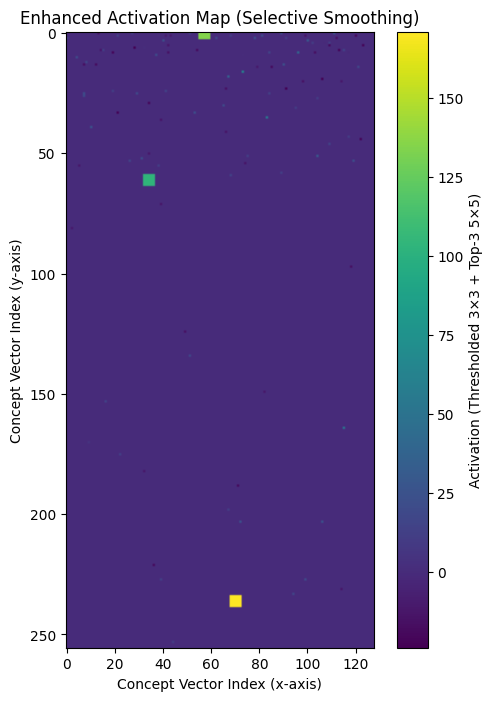

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data
data = plotnormed_sparsedspace_post.clone().numpy().reshape(256, 128).copy()
height, width = data.shape
data_smoothed = data.copy()

# 2. Threshold: 35% of the dynamic range
vmin, vmax = data.min(), data.max()
threshold = vmin + 0.35 * (vmax - vmin)

# 3. Apply 3×3 window for values above threshold
for r in range(height):
    for c in range(width):
        if data[r, c] > threshold:
            val = data[r, c]
            r0 = max(0, r - 1)
            r1 = min(height, r + 2)
            c0 = max(0, c - 1)
            c1 = min(width, c + 2)
            data_smoothed[r0:r1, c0:c1] = val

# 4. Apply 5×5 window for top-3 peaks
flat = data.flatten()
top3_idx = np.argsort(flat)[-3:]
coords = [(idx // width, idx % width) for idx in top3_idx]

for r, c in coords:
    val = data[r, c]
    r0 = max(0, r - 2)
    r1 = min(height, r + 3)
    c0 = max(0, c - 2)
    c1 = min(width, c + 3)
    data_smoothed[r0:r1, c0:c1] = val

# 5. Plot the result
plt.figure(figsize=(6, 8))
plt.imshow(data_smoothed, cmap='viridis')
plt.colorbar(label="Activation (Thresholded 3×3 + Top-3 5×5)")
plt.xlabel("Concept Vector Index (x-axis)")
plt.ylabel("Concept Vector Index (y-axis)")
plt.title("Enhanced Activation Map (Selective Smoothing)")
plt.show()


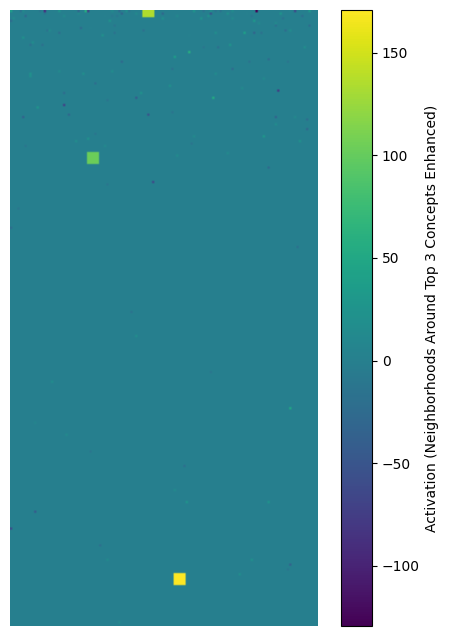

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data
data = plotnormed_sparsedspace_post.clone().numpy().reshape(256, 128).copy()
height, width = data.shape

# 2. Find top-3 peaks
flat = data.flatten()
top3_idx = np.argsort(flat)[-3:]
coords = [(idx // width, idx % width) for idx in top3_idx]

# 3. Apply 10×10 square around each peak
half = 2  # for a 10×10 window

for r, c in coords:
    center_val = data[r, c]
    
    # Compute bounds, clip to array limits
    r0 = max(0, r - half)
    r1 = min(height, r + half + 1)
    c0 = max(0, c - half)
    c1 = min(width, c + half + 1)
    
    # Set neighborhood to center value
    data[r0:r1, c0:c1] = center_val

# 4. Plot modified data
plt.figure(figsize=(6, 8))
plt.imshow(data, cmap='viridis')
plt.colorbar(label="Activation (Neighborhoods Around Top 3 Concepts Enhanced)")
plt.xlabel("Concept Vector Index x-axis")
plt.ylabel("Concept Vector Index y-axis")
plt.axis('off')
plt.show()


### In sparse space, we see three heavy activations. We will utilise these to steer the model's predictions

space post


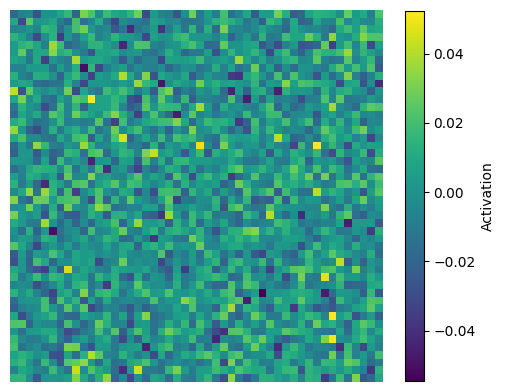

In [43]:
import math
print("space post")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap



plotnormed_sparsedspace_posteeeee = torch.mean(gemma_2_2b_sae.W_dec[latent_idx],dim=0,keepdim=False)


# Your data
data = plotnormed_sparsedspace_posteeeee.clone().detach().cpu().numpy().reshape(48,48)

# Plot
plt.figure(figsize=(6, 8))
plt.imshow(data)
plt.colorbar(label="Activation", shrink=0.6)
plt.xlabel("Hidden Neurons Index X-axis ")
plt.ylabel("Hidden Neurons Index Y-axis ")
plt.axis('off')

plt.show()

space post


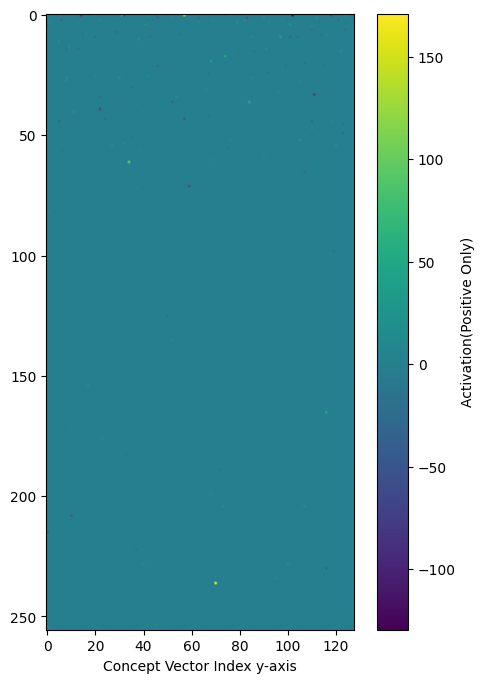

In [20]:
import math
print("space post")
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap

# Your data
data = plotnormed_sparsedspace_post.clone().numpy().reshape(256, 128)

# Plot
plt.figure(figsize=(6, 8))
plt.imshow(data)
plt.colorbar(label="Activation(Positive Only)")
plt.xlabel("Concept Vector Index x-axis")
plt.xlabel("Concept Vector Index y-axis")
plt.show()

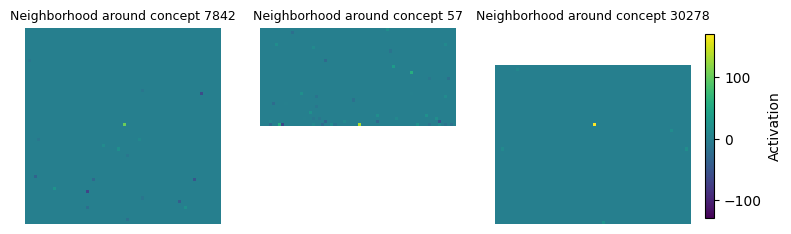

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data
data = plotnormed_sparsedspace_post.clone().numpy().reshape(256, 128)

# 2. Find top-3 peaks (flattened indices)
flat = data.flatten()
top3_idx = np.argsort(flat)[-3:]
coords = [(idx // data.shape[1], idx % data.shape[1]) for idx in top3_idx]

# 3. Define neighborhood and pad
half = 32
pad = half
padded = np.pad(data,
                ((pad, pad), (pad, pad)),
                mode='constant',
                constant_values=np.nan)

# 4. Global min/max for consistent colormap
vmin, vmax = np.nanmin(data), np.nanmax(data)

# 5. Plot with smaller layout
fig, axs = plt.subplots(1, 3, figsize=(9, 3))  # smaller figure
for ax, concept_idx, (r, c) in zip(axs, top3_idx, coords):
    rp, cp = r + pad, c + pad
    region = padded[rp-half:rp+half, cp-half:cp+half]
    
    im = ax.imshow(region, cmap='viridis', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_title(f"Neighborhood around concept {concept_idx}", fontsize=9)
    ax.axis('off')

# 6. Smaller colorbar
fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.025, pad=0.02,
             label="Activation", shrink=0.8)


plt.show()


In [22]:
vals, indices = torch.sort(normed_sparsedspace_post,descending=True) # llooking at high activs
indices_high = torch.where(vals> 0)

inspect_list = [] 
for i in zip(vals[indices_high],indices[indices_high]):
    inspect_list.append(i)

indices_inspect = indices[indices_high]
inspect_list 

[(tensor(170.8639), tensor(30278)),
 (tensor(134.8190), tensor(57)),
 (tensor(103.6199), tensor(7842)),
 (tensor(58.8274), tensor(2250)),
 (tensor(58.0422), tensor(31)),
 (tensor(52.5674), tensor(4692)),
 (tensor(48.5439), tensor(21236)),
 (tensor(38.4010), tensor(1249)),
 (tensor(35.5497), tensor(0)),
 (tensor(35.2027), tensor(2500)),
 (tensor(28.9279), tensor(6761)),
 (tensor(28.0526), tensor(124)),
 (tensor(27.9750), tensor(613)),
 (tensor(25.2579), tensor(240)),
 (tensor(24.6426), tensor(5131)),
 (tensor(23.8652), tensor(26185)),
 (tensor(23.4646), tensor(26219)),
 (tensor(23.0724), tensor(1883)),
 (tensor(22.7492), tensor(20)),
 (tensor(21.9779), tensor(76)),
 (tensor(21.5769), tensor(3336)),
 (tensor(21.4425), tensor(463)),
 (tensor(21.3006), tensor(4406)),
 (tensor(21.0946), tensor(553)),
 (tensor(20.5191), tensor(7032)),
 (tensor(20.1927), tensor(1413)),
 (tensor(19.9097), tensor(6816)),
 (tensor(19.8959), tensor(1318)),
 (tensor(19.5454), tensor(218)),
 (tensor(19.4506), tenso

In [23]:
import torch 
#latent_idx = int(indices_inspect[0].item())

#latent_idx = [indices_inspect[0],indices_inspect[5]] #layer 21

#latent_idx = [indices_inspect[0].item(), indices_inspect[2].item()] #layer 22: emojois + slang

#latent_idx = indices_inspect[0:3] #layer 23

#latent_idx = indices_inspect[0:3]#.item() #layer 24      # 10 is "face"/ emotion indices_inspect[10].item() , 2 is slang/emojis, 0 more emojis

latent_idx = [indices_inspect[0].item(),indices_inspect[2].item()] # layer 24

def steering_hook_sparsespace(
    activations: Float[Tensor, "batch pos d_in"],
    hook: HookPoint,
    sae: SAE,
    latent_idx: int,
    steering_coefficient: float,
) -> Tensor:
    """
    Steers the model by returning a modified activations tensor, with some multiple of the steering vector added to all
    sequence positions.
    """
    # w_dec gets for a certain sparse space idx the activations pattern, and then we add it
    if isinstance(latent_idx,int):
        return activations + steering_coefficient *sae.W_dec[latent_idx] #Hmm wow how can we visualize this - interesting. Pretty simple in a way.
    else: #multi indx
        #print("enhancing multiple concepts")
        return activations + steering_coefficient *torch.mean(sae.W_dec[latent_idx],dim=0,keepdim=False) #Hmm wow how can we visualize this - interesting. Pretty simple in a way.




_steering_hook = partial(
    steering_hook_sparsespace,
    sae=gemma_2_2b_sae,
    latent_idx=latent_idx,
    steering_coefficient=600,
)

with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
  utils.test_prompt(prompt_word, "🙂", gemma_2_2b)

Tokenized prompt: ['<bos>', 'A', ' random', ' English', ' word', ':', '\n', 'sun', '\n', 'river', '\n', 'cloud', '\n', 'stone', '\n', 'forest', '\n', 'cold', '\n', 'mirror', '\n']
Tokenized answer: [' 🙂']


Performance on answer token:
Rank: 55923    Logit:  6.36 Prob:  0.00% Token: | 🙂|

Top 0th token. Logit: 24.94 Prob:  7.91% Token: |🔥|
Top 1th token. Logit: 24.35 Prob:  4.35% Token: | 🔥|
Top 2th token. Logit: 23.96 Prob:  2.96% Token: |moon|
Top 3th token. Logit: 23.79 Prob:  2.51% Token: |🍃|
Top 4th token. Logit: 23.77 Prob:  2.45% Token: |🥺|
Top 5th token. Logit: 23.75 Prob:  2.39% Token: |💀|
Top 6th token. Logit: 23.63 Prob:  2.13% Token: | 💀|
Top 7th token. Logit: 23.53 Prob:  1.92% Token: |✨|
Top 8th token. Logit: 23.44 Prob:  1.75% Token: |🌊|
Top 9th token. Logit: 23.42 Prob:  1.72% Token: |fire|


Ranks of the answer tokens: [(' 🙂', 55923)]

In [24]:
# original 
utils.test_prompt(prompt_word, "🙂", gemma_2_2b)

Tokenized prompt: ['<bos>', 'A', ' random', ' English', ' word', ':', '\n', 'sun', '\n', 'river', '\n', 'cloud', '\n', 'stone', '\n', 'forest', '\n', 'cold', '\n', 'mirror', '\n']
Tokenized answer: [' 🙂']


Performance on answer token:
Rank: 91943    Logit:  2.40 Prob:  0.00% Token: | 🙂|

Top 0th token. Logit: 25.87 Prob:  5.04% Token: |tree|
Top 1th token. Logit: 25.77 Prob:  4.54% Token: |wind|
Top 2th token. Logit: 25.68 Prob:  4.15% Token: |moon|
Top 3th token. Logit: 25.57 Prob:  3.72% Token: |fire|
Top 4th token. Logit: 25.42 Prob:  3.19% Token: |sun|
Top 5th token. Logit: 25.39 Prob:  3.11% Token: |snow|
Top 6th token. Logit: 25.27 Prob:  2.76% Token: |mountain|
Top 7th token. Logit: 25.24 Prob:  2.66% Token: |water|
Top 8th token. Logit: 25.12 Prob:  2.36% Token: |sky|
Top 9th token. Logit: 25.10 Prob:  2.32% Token: |lake|


Ranks of the answer tokens: [(' 🙂', 91943)]

# Generate with tweak


In [25]:
context = "Afterwards he"

sample_tokens = True
preprend_bos_token = True
samples = 3 

In [ ]:
# without tweak
for i in range(samples):
    print(gemma_2_2b.generate(context,prepend_bos=preprend_bos_token,do_sample=sample_tokens,temperature=1.5, freq_penalty=2.0, verbose=False))


Afterwards he left somewhere where on it for work there were lots
Afterwards he said :You haven is tea ice, apple cider
Afterwards he spent many years looking through pictures taken before ww2


In [30]:
# with tweak
with gemma_2_2b.hooks(fwd_hooks=[(gemma_2_2b_sae.cfg.hook_name, _steering_hook)]):
    for i in range(samples):
        print(gemma_2_2b.generate(context,prepend_bos=preprend_bos_token,do_sample=sample_tokens,temperature=1.5, freq_penalty=2.0, verbose=False))
    

Afterwards he filmed⚔🏆 💀🧊 😂🎄🍵🇵🔟
Afterwards he had🗣 🥲🍑👀😈💙🤲 🤣👏
Afterwards he was asked second😂😂😂👆 🤣🤦🤭 Biden 🔥🔥


#### Clearly, using the sparse steering method, we can influence the model such that it predictions include emojis
#### The found concepts in sparse space thus might represent the concept "emoji". Furthermore, we see an increase in slang usage during generation with the steering, pointing to an internal connection between slang and emoji usage in LLMs